# Settimana 2 — Training su Flickr30k

Stesso modello (ViT-base + GPT-2 small), stesse tecniche dello Scenario B,
ma su Flickr30k: ~4x più dati di training (140k caption vs 30k).

## Obiettivo
- Atteso BLEU-4 ~13-17 sul test Flickr30k
- Atteso BLEU-4 ~12-15 sul test Flickr8k (per confronto diretto col baseline e Scenario B)

## Cosa cambia rispetto allo Scenario B (notebook 05)
| Aspetto | Scenario B | Settimana 2 (questo) |
|---------|------------|---------------------|
| Dataset | Flickr8k (8091 imgs) | Flickr30k (31783 imgs) |
| Train | 6000 imgs / 30k caption | 27971 imgs / 140k caption |
| Val | 1000 imgs | 1906 imgs |
| Test | 1091 imgs | 1906 imgs |
| Tempo/epoca | ~6.6 min | ~30 min stimato |
| Tempo totale | ~1 ora | ~4-6 ore stimate |

Iperparametri identici (LR, batch size, augmentation, scheduler, label smoothing).
Tutto il resto come da Scenario B.

## Protocollo di valutazione
A fine training, valuteremo il modello su DUE test set:
1. Test Flickr30k (1906 imgs) — dataset nativo
2. Test Flickr8k (1091 imgs) — confronto diretto con baseline e Scenario B

(Verificato precedentemente: zero overlap tra test Flickr8k e train Flickr30k → no leakage)

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torchvision.transforms as T
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from transformers import (
    VisionEncoderDecoderModel,
    GPT2Tokenizer,
    ViTImageProcessor,
)
import sacrebleu
from tqdm.auto import tqdm
import time
import json
import math
import shutil
import matplotlib.pyplot as plt

# Riproducibilita'
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Path del progetto - QUESTA E' LA DIFFERENZA CHIAVE
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "flickr30k"           # <- Flickr30k invece di Flickr8k
IMAGES_DIR = DATA_DIR / "flickr30k_images"               # <- nome cartella diverso
SPLIT_FILE = DATA_DIR / "captions_with_split.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
INITIAL_MODEL_DIR = CHECKPOINT_DIR / "model_initial"
WEEK2_DIR = CHECKPOINT_DIR / "week2_flickr30k"           # <- nuova dir per i checkpoint
WEEK2_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

# Iperparametri (identici allo Scenario B)
NUM_EPOCHS = 10                  # budget ridotto: con 4x piu' dati, meno epoche servono
EARLY_STOP_PATIENCE = 3
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 1/10
BATCH_SIZE = 32
NUM_WORKERS = 0
MAX_LENGTH = 30
GRAD_CLIP = 1.0
LABEL_SMOOTHING = 0.1
VAL_BLEU_SUBSET_SIZE = 300       # un po' piu' grande per stabilita' (Flickr30k val e' 1906 imgs)

print(f"\n=== Iperparametri Settimana 2 ===")
print(f"Dataset:                Flickr30k")
print(f"Budget epoche:          {NUM_EPOCHS}")
print(f"Early stopping:         {EARLY_STOP_PATIENCE} epoche senza miglioramento BLEU")
print(f"Peak learning rate:     {LEARNING_RATE}")
print(f"Warmup ratio:           {WARMUP_RATIO:.3f}")
print(f"Label smoothing:        {LABEL_SMOOTHING}")
print(f"Batch size:             {BATCH_SIZE}")
print(f"Val BLEU subset size:   {VAL_BLEU_SUBSET_SIZE}")

Device: cuda
GPU: NVIDIA GeForce RTX 5070

=== Iperparametri Settimana 2 ===
Dataset:                Flickr30k
Budget epoche:          10
Early stopping:         3 epoche senza miglioramento BLEU
Peak learning rate:     5e-05
Warmup ratio:           0.100
Label smoothing:        0.1
Batch size:             32
Val BLEU subset size:   300


In [6]:
# Statistiche di normalizzazione di ImageNet (stesse di Scenario B)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Trasformazioni di TRAINING: con augmentation (identico a Scenario B)
train_transforms = T.Compose([
    T.RandomResizedCrop(size=224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Trasformazioni di VALIDAZIONE/TEST: pulite (identico a Scenario B)
eval_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class Flickr30kCaptionsDataset(Dataset):
    """Dataset PyTorch per Flickr30k. Identica al Flickr8kDataset dello Scenario B,
    cambia solo il nome (e la cartella delle immagini dall'esterno)."""
    
    def __init__(self, df_split, images_dir, transforms_fn, tokenizer, max_length=30):
        self.df = df_split.reset_index(drop=True)
        self.images_dir = images_dir
        self.transforms = transforms_fn
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.images_dir / row['image']
        image = Image.open(img_path).convert("RGB")
        pixel_values = self.transforms(image)
        
        caption = row['caption']
        text = self.tokenizer.bos_token + " " + caption + " " + self.tokenizer.eos_token
        encoding = self.tokenizer(
            text, padding="max_length", max_length=self.max_length,
            truncation=True, return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        
        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "image_filename": row['image'],
            "caption_text": caption,
        }


# Carico il modello iniziale (lo stesso snapshot vergine usato in Scenario A e B)
print("Caricamento modello iniziale (snapshot vergine, mai addestrato)...")
model = VisionEncoderDecoderModel.from_pretrained(INITIAL_MODEL_DIR)
tokenizer = GPT2Tokenizer.from_pretrained(INITIAL_MODEL_DIR)
image_processor = ViTImageProcessor.from_pretrained(INITIAL_MODEL_DIR)
tokenizer.pad_token = tokenizer.eos_token
model = model.to(device)
print(f"Modello su {device}, {sum(p.numel() for p in model.parameters())/1e6:.1f}M parametri")

# Carico split Flickr30k
df = pd.read_csv(SPLIT_FILE)
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']

train_dataset = Flickr30kCaptionsDataset(train_df, IMAGES_DIR, train_transforms, tokenizer, MAX_LENGTH)
val_dataset = Flickr30kCaptionsDataset(val_df, IMAGES_DIR, eval_transforms, tokenizer, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"\nTrain: {len(train_dataset)} esempi, {len(train_loader)} batch (con augmentation)")
print(f"Val:   {len(val_dataset)} esempi, {len(val_loader)} batch (senza augmentation)")

Caricamento modello iniziale (snapshot vergine, mai addestrato)...
Modello su cuda, 239.2M parametri

Train: 139855 esempi, 4371 batch (con augmentation)
Val:   9530 esempi, 298 batch (senza augmentation)


Total training steps: 43710
Warmup steps:         4371 (10.0% del totale)
Loss: CrossEntropyLoss con label_smoothing=0.1
Mixed precision: attiva (bfloat16)


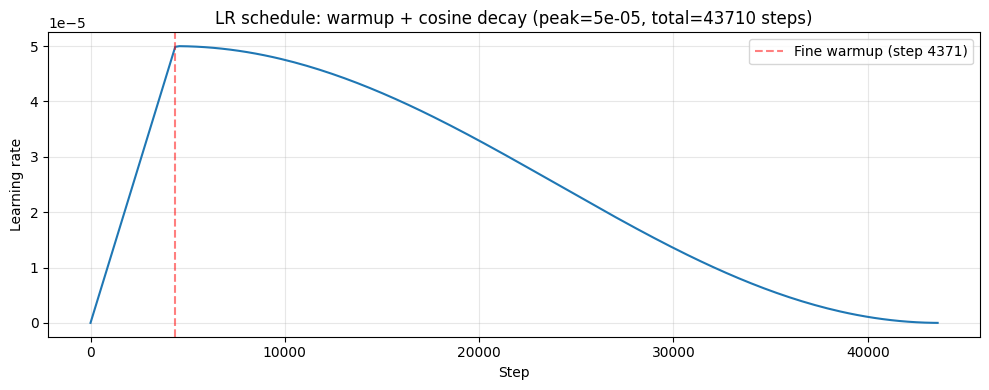

In [7]:
# === Optimizer ===
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# === LR Scheduler: warmup linear + cosine decay ===
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

def lr_lambda(current_step: int):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    else:
        progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps:         {warmup_steps} ({warmup_steps/total_steps*100:.1f}% del totale)")

# === Label smoothing loss ===
loss_fn = nn.CrossEntropyLoss(
    ignore_index=-100,
    label_smoothing=LABEL_SMOOTHING,
)
print(f"Loss: CrossEntropyLoss con label_smoothing={LABEL_SMOOTHING}")

# === Mixed precision ===
use_amp = torch.cuda.is_bf16_supported()
amp_dtype = torch.bfloat16 if use_amp else torch.float32
print(f"Mixed precision: {'attiva (bfloat16)' if use_amp else 'non disponibile'}")

# Grafico del LR
fig, ax = plt.subplots(figsize=(10, 4))
test_steps = list(range(0, total_steps + 1, max(1, total_steps // 200)))
test_lrs = [LEARNING_RATE * lr_lambda(s) for s in test_steps]
ax.plot(test_steps, test_lrs)
ax.axvline(warmup_steps, color='red', linestyle='--', alpha=0.5,
           label=f'Fine warmup (step {warmup_steps})')
ax.set_xlabel('Step')
ax.set_ylabel('Learning rate')
ax.set_title(f'LR schedule: warmup + cosine decay (peak={LEARNING_RATE}, total={total_steps} steps)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
def compute_loss_with_smoothing(outputs, labels, loss_fn):
    """Calcola la loss con label smoothing.
    
    VisionEncoderDecoderModel shifta gia' i labels internamente, quindi
    confrontiamo logits e labels direttamente senza shift manuale.
    """
    logits = outputs.logits
    loss = loss_fn(
        logits.view(-1, logits.size(-1)),
        labels.view(-1),
    )
    return loss


def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device, epoch):
    model.train()
    total_loss = 0.0
    n_batches = len(loader)
    
    pbar = tqdm(loader, desc=f"Epoca {epoch} [train]", leave=False)
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=use_amp):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = compute_loss_with_smoothing(outputs, labels, loss_fn)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        current_lr = scheduler.get_last_lr()[0]
        pbar.set_postfix({'loss': f'{loss.item():.3f}', 'lr': f'{current_lr:.2e}'})
    
    return total_loss / n_batches


@torch.no_grad()
def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    n_batches = len(loader)
    
    for batch in tqdm(loader, desc="Val [loss]", leave=False):
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        
        with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=use_amp):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = compute_loss_with_smoothing(outputs, labels, loss_fn)
        
        total_loss += loss.item()
    
    return total_loss / n_batches


@torch.no_grad()
def generate_caption_batch(model, pixel_values_batch, tokenizer, device):
    batch_size = pixel_values_batch.size(0)
    decoder_input_ids = torch.tensor(
        [[tokenizer.bos_token_id, tokenizer.bos_token_id]] * batch_size,
        device=device,
    )
    output_ids = model.generate(
        pixel_values=pixel_values_batch,
        decoder_input_ids=decoder_input_ids,
        max_length=MAX_LENGTH,
        num_beams=4,
        early_stopping=True,
        no_repeat_ngram_size=3,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        bos_token_id=tokenizer.bos_token_id,
    )
    return [tokenizer.decode(ids, skip_special_tokens=True).strip() for ids in output_ids]


@torch.no_grad()
def evaluate_bleu_subset(model, val_df, images_dir, eval_transforms,
                         tokenizer, device, n_samples=300, batch_size=16):
    model.eval()
    unique_imgs = val_df['image'].unique()
    rng = np.random.default_rng(seed=42)
    sampled_imgs = rng.choice(unique_imgs, size=min(n_samples, len(unique_imgs)), replace=False)
    
    generated_captions = []
    references_per_image = []
    
    for batch_start in tqdm(range(0, len(sampled_imgs), batch_size), desc="Val [BLEU]", leave=False):
        batch_imgs = sampled_imgs[batch_start:batch_start + batch_size]
        pixel_values_list = []
        for img_name in batch_imgs:
            image = Image.open(images_dir / img_name).convert("RGB")
            pixel_values_list.append(eval_transforms(image))
        pixel_values_batch = torch.stack(pixel_values_list).to(device)
        
        with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=use_amp):
            batch_captions = generate_caption_batch(model, pixel_values_batch, tokenizer, device)
        
        for img_name, gen_cap in zip(batch_imgs, batch_captions):
            generated_captions.append(gen_cap)
            refs = val_df[val_df['image'] == img_name]['caption'].tolist()
            references_per_image.append(refs)
    
    references_transposed = [list(refs) for refs in zip(*references_per_image)]
    bleu = sacrebleu.corpus_bleu(generated_captions, references_transposed)
    
    return {
        'BLEU-1': bleu.precisions[0],
        'BLEU-2': bleu.precisions[1],
        'BLEU-3': bleu.precisions[2],
        'BLEU-4': bleu.precisions[3],
        'BLEU_corpus': bleu.score,
        'n_samples': len(sampled_imgs),
    }


print("Funzioni di train e validation definite.")
print(f"  evaluate_bleu_subset valuta su {VAL_BLEU_SUBSET_SIZE} immagini del val set")

Funzioni di train e validation definite.
  evaluate_bleu_subset valuta su 300 immagini del val set


In [9]:
history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_bleu_1': [],
    'val_bleu_4': [],
    'val_bleu_corpus': [],
    'lr_at_end_of_epoch': [],
    'epoch_time_sec': [],
}

best_bleu4 = -1.0
best_epoch = 0
epochs_since_improvement = 0
HISTORY_FILE = OUTPUTS_DIR / "week2_flickr30k_history.json"
BEST_DIR = WEEK2_DIR / "best"
LAST_DIR = WEEK2_DIR / "last"

print(f"=== Avvio training Settimana 2 (Flickr30k) ===")
print(f"Budget: {NUM_EPOCHS} epoche, early stopping con patience {EARLY_STOP_PATIENCE}")
print(f"Stima conservativa tempo totale: 5-6 ore (puo' fermarsi prima per early stop)")
print(f"Best model in: {BEST_DIR}")
print(f"Last model in: {LAST_DIR}")
print()

overall_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device, epoch)
    val_loss = evaluate_loss(model, val_loader, loss_fn, device)
    val_bleu = evaluate_bleu_subset(
        model, val_df, IMAGES_DIR, eval_transforms,
        tokenizer, device, n_samples=VAL_BLEU_SUBSET_SIZE, batch_size=16,
    )
    
    epoch_time = time.time() - epoch_start
    current_lr = scheduler.get_last_lr()[0]
    
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_bleu_1'].append(val_bleu['BLEU-1'])
    history['val_bleu_4'].append(val_bleu['BLEU-4'])
    history['val_bleu_corpus'].append(val_bleu['BLEU_corpus'])
    history['lr_at_end_of_epoch'].append(current_lr)
    history['epoch_time_sec'].append(epoch_time)
    
    with open(HISTORY_FILE, "w") as f:
        json.dump(history, f, indent=2)
    
    # Salva sempre il "last" (antinfortunistica)
    if LAST_DIR.exists():
        shutil.rmtree(LAST_DIR)
    model.save_pretrained(LAST_DIR)
    
    # Salva il "best" solo se BLEU-4 migliora
    is_best = val_bleu['BLEU-4'] > best_bleu4
    if is_best:
        best_bleu4 = val_bleu['BLEU-4']
        best_epoch = epoch
        epochs_since_improvement = 0
        if BEST_DIR.exists():
            shutil.rmtree(BEST_DIR)
        model.save_pretrained(BEST_DIR)
        marker = "[BEST!]"
    else:
        epochs_since_improvement += 1
        marker = f"(no improv x{epochs_since_improvement})"
    
    print(f"Epoca {epoch:2d}/{NUM_EPOCHS} | "
          f"train: {train_loss:.3f} | val: {val_loss:.3f} | "
          f"BLEU-1: {val_bleu['BLEU-1']:.2f} | "
          f"BLEU-4: {val_bleu['BLEU-4']:.2f} | "
          f"lr: {current_lr:.2e} | "
          f"tempo: {epoch_time/60:.1f}min | "
          f"{marker}")
    
    if epochs_since_improvement >= EARLY_STOP_PATIENCE:
        print(f"\n>>> Early stopping: BLEU-4 non migliora da {EARLY_STOP_PATIENCE} epoche consecutive")
        break

total_time = time.time() - overall_start
print(f"\n=== Training completato in {total_time/60:.1f} minuti ({total_time/3600:.1f} ore) ===")
print(f"Best epoca:  {best_epoch}")
print(f"Best BLEU-4: {best_bleu4:.2f}")
print(f"Best model salvato in: {BEST_DIR}")
print(f"Last model salvato in: {LAST_DIR}")

=== Avvio training Settimana 2 (Flickr30k) ===
Budget: 10 epoche, early stopping con patience 3
Stima conservativa tempo totale: 5-6 ore (puo' fermarsi prima per early stop)
Best model in: c:\dev\image-captioning\checkpoints\week2_flickr30k\best
Last model in: c:\dev\image-captioning\checkpoints\week2_flickr30k\last



Epoca 1 [train]:   0%|          | 0/4371 [00:00<?, ?it/s]

Val [loss]:   0%|          | 0/298 [00:00<?, ?it/s]

Val [BLEU]:   0%|          | 0/19 [00:00<?, ?it/s]

c:\dev\image-captioning\.venv\Lib\site-packages\transformers\generation\utils.py:1375: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation pa

...

Epoca 8 [train]:   0%|          | 0/4371 [00:00<?, ?it/s]

Val [loss]:   0%|          | 0/298 [00:00<?, ?it/s]

Val [BLEU]:   0%|          | 0/19 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 30, 'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}


Epoca  8/10 | train: 2.652 | val: 3.350 | BLEU-1: 69.86 | BLEU-4: 10.20 | lr: 5.85e-06 | tempo: 27.4min | (no improv x3)

>>> Early stopping: BLEU-4 non migliora da 3 epoche consecutive

=== Training completato in 220.9 minuti (3.7 ore) ===
Best epoca:  5
Best BLEU-4: 11.11
Best model salvato in: c:\dev\image-captioning\checkpoints\week2_flickr30k\best
Last model salvato in: c:\dev\image-captioning\checkpoints\week2_flickr30k\last
